# Scrape Google Trends for Your Own Topic - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 1, 3:30 session.** You drive a coding agent (Codex, Claude Code, or
Antigravity CLI) to pull Google Trends for **your own** disease and place, and keep the
judgment. For each step: read the goal, paste the **prompt**, run the code, apply the check.

> Each prompt produces roughly the matching cell in the **Lane B** notebook. Not set up
> with an agent yet? Use Lane B. Default example topic: flu in the US.


## Step 0: set up a robust fetch, and pick your topic

> *Using pytrends, write `gt_fetch(kw_list, timeframe, geo)` that returns a tidy DataFrame*
> *(date + one column per entry, underscored names) and accepts literal phrases, additive*
> *"a + b" queries, or topic mids. Build TrendReq with retries and a small random pause;*
> *on a 429 wait ~10s and retry a few times; return None (not raise) if it still fails.*
> *Also write `topic_mid(phrase)` that resolves a phrase to a Google Trends topic entity*
> *via pytrends suggestions, and a loader for the cached example CSV in data/. Then set*
> *two variables I will edit: MY_TERMS (my disease's query phrases) and MY_GEO.*


In [1]:
from pytrends.request import TrendReq   # pip install pytrends (in requirements.txt)
import pandas as pd, time, random, os

# ===== EDIT THESE TWO LINES for your own topic =====
MY_TERMS = ['RSV', 'respiratory syncytial virus', 'RSV symptoms']   # query phrases, max 5
MY_GEO   = 'US'                                                     # e.g. 'US', 'MX', 'US-GA', 'BR'
# ===================================================
RECENT_TF = 'today 5-y'   # past 5 years; last point is the current week

# a cached example (flu, US) so this notebook still runs even if the live pull is blocked
CACHE_PATHS = [
    '../data/google_trends_flu_us_cached.csv',
    'data/google_trends_flu_us_cached.csv',
    './google_trends_flu_us_cached.csv',
]

def _norm(c):
    return c.strip().replace(' ', '_')

def gt_fetch(kw_list, timeframe, geo, tries=4):
    """Google Trends interest-over-time for a handful of terms/topics (max 5).
    kw_list entries can be literal phrases, additive queries like 'flu + gripe',
    or topic mids like '/m/0cycc'. Returns a tidy DataFrame (date + one column
    per entry), or None if Google keeps refusing."""
    time.sleep(random.uniform(0, 3))   # stagger: do not all hit Google at once
    for attempt in range(tries):
        try:
            pt = TrendReq(hl='en-US', tz=360, retries=2, backoff_factor=0.5)
            pt.build_payload(kw_list, timeframe=timeframe, geo=geo)
            df = pt.interest_over_time()
            if df.empty:
                raise RuntimeError('empty frame (rate-limited)')
            df = df.drop(columns=[c for c in ['isPartial'] if c in df.columns]).reset_index()
            return df.rename(columns={c: _norm(c) for c in df.columns})
        except Exception as e:
            rate_limited = ('429' in str(e) or 'empty frame' in str(e)
                            or 'toomany' in type(e).__name__.lower())
            if rate_limited and attempt < tries - 1:
                wait = 10 * (attempt + 1)
                print(f'Rate-limited (attempt {attempt+1}/{tries}); waiting {wait}s and retrying...')
                time.sleep(wait)
                continue
            print(f'Live Google Trends pull failed ({type(e).__name__}): {e}')
            return None
    return None

def topic_mid(phrase):
    """Resolve a phrase to a Google Trends TOPIC entity (a Knowledge Graph 'mid'
    like '/m/0cycc') via pytrends suggestions. Falls back to the literal phrase
    if lookup fails."""
    try:
        s = TrendReq(hl='en-US', tz=360).suggestions(phrase)
        if s:
            return s[0]['mid'], s[0]['title'], s[0]['type']
    except Exception as e:
        print('suggestions lookup failed:', e)
    return phrase, phrase, 'raw term'

def load_cache():
    for p in CACHE_PATHS:
        if os.path.exists(p):
            print(f'Using cached example (flu, US) — not RSV, but keeps the notebook runnable: {p}')
            return pd.read_csv(p, parse_dates=['date'])
    raise FileNotFoundError('Cached example not found; check the data/ folder.')


## Step 1: pull your terms, live

> *Use gt_fetch to pull MY_TERMS for MY_GEO over the past 5 years (today 5-y). If it*
> *returns None, fall back to the cached example. Plot the series and print the last date.*

**Your check:** does the last point land on the current week, and do peaks fall in a
plausible season for your disease and place?


rows: 262 | last data point: 2026-07-19


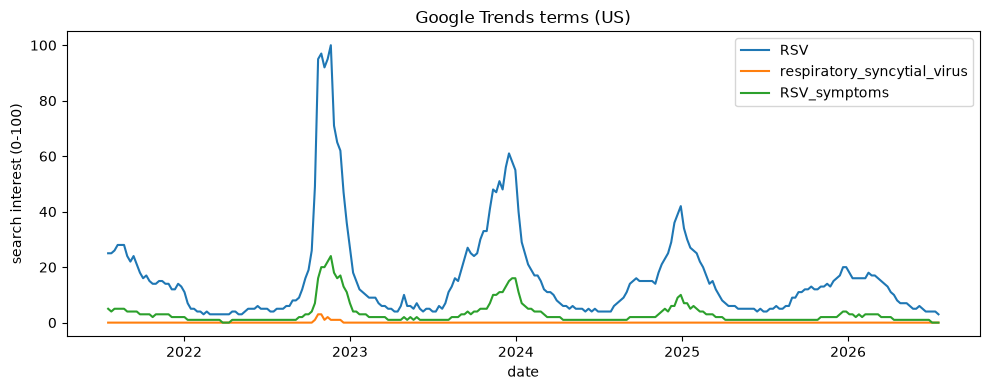

,date,RSV,respiratory_syncytial_virus,RSV_symptoms
257,2026-06-21,4,0,1
258,2026-06-28,4,0,1
259,2026-07-05,4,0,0
260,2026-07-12,4,0,0
261,2026-07-19,3,0,0


In [2]:
import matplotlib.pyplot as plt

series = gt_fetch(MY_TERMS, timeframe=RECENT_TF, geo=MY_GEO)
if series is None:
    series = load_cache()

cols = [c for c in series.columns if c != 'date']
print('rows:', len(series), '| last data point:', series['date'].max().date())

plt.figure(figsize=(10, 4))
for c in cols:
    plt.plot(series['date'], series[c], label=c)
plt.legend(); plt.title(f'Google Trends terms ({MY_GEO})')
plt.ylabel('search interest (0-100)'); plt.xlabel('date'); plt.tight_layout(); plt.show()
series.tail()


## Step 2: term vs topic

> *Compare three ways to get the signal: (1) the individual terms, (2) one combined*
> *additive query joining the phrases with ' + ' (a topic-like OR), and (3) the real*
> *Google Trends topic entity, resolved with topic_mid and pulled by its mid. Report the*
> *percent of zeros for each, and overlay them on one plot. Which has the fewest zeros and*
> *the cleanest seasonal signal?*

**Why it matters:** a raw term misses synonyms, spellings, and languages; a topic folds
them in, with more volume and fewer zeros.


'RSV' resolves to -> RSVLTS (Topic), mid=/g/11rc9npj_b



% zeros, individual terms:
RSV                             0.0
respiratory_syncytial_virus    96.6
RSV_symptoms                    2.3
dtype: float64
% zeros, combined "+" query: 0.0
% zeros, topic entity RSVLTS: 6.9


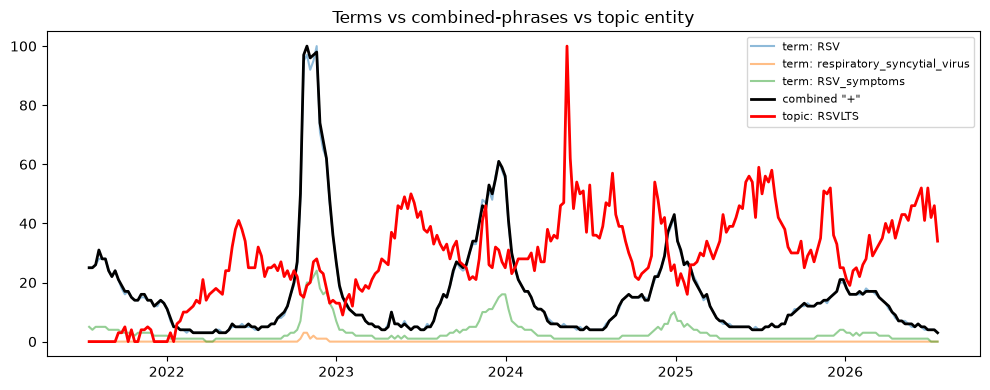


fewest zeros: term: RSV (0.0% zeros)
strongest seasonal signal (highest std dev): combined "+" (std=17.2)


In [3]:
live = gt_fetch(MY_TERMS, RECENT_TF, MY_GEO)                     # (1) individual terms
combo_query = ' + '.join(MY_TERMS)
combo = gt_fetch([combo_query], RECENT_TF, MY_GEO)                # (2) combined "+" query
mid, title, kind = topic_mid(MY_TERMS[0])
print(f"'{MY_TERMS[0]}' resolves to -> {title} ({kind}), mid={mid}")
topic = gt_fetch([mid], RECENT_TF, MY_GEO) if mid != MY_TERMS[0] else None   # (3) real topic entity

if live is not None:
    tcols = [c for c in live.columns if c != 'date']
    pct_zero = (live[tcols] == 0).mean().mul(100).round(1)
    print('\n% zeros, individual terms:'); print(pct_zero)

    summary = {}
    for c in tcols:
        summary[f'term: {c}'] = (float(pct_zero[c]), float(live[c].std()))

    if combo is not None:
        ccol = [c for c in combo.columns if c != 'date'][0]
        combo_pct_zero = float((combo[ccol] == 0).mean() * 100)
        print(f'% zeros, combined "+" query: {combo_pct_zero:.1f}')
        summary['combined "+"'] = (combo_pct_zero, float(combo[ccol].std()))

    if topic is not None:
        pcol = [c for c in topic.columns if c != 'date'][0]
        topic_pct_zero = float((topic[pcol] == 0).mean() * 100)
        print(f'% zeros, topic entity {title}: {topic_pct_zero:.1f}')
        summary[f'topic: {title}'] = (topic_pct_zero, float(topic[pcol].std()))

    plt.figure(figsize=(10, 4))
    for c in tcols:
        plt.plot(live['date'], live[c], alpha=0.5, label=f'term: {c}')
    if combo is not None:
        plt.plot(combo['date'], combo[ccol], 'k', lw=2, label='combined "+"')
    if topic is not None:
        plt.plot(topic['date'], topic[pcol], 'r', lw=2, label=f'topic: {title}')
    plt.legend(fontsize=8); plt.title('Terms vs combined-phrases vs topic entity')
    plt.tight_layout(); plt.show()

    print('\nfewest zeros:', min(summary, key=lambda k: summary[k][0]),
          f"({summary[min(summary, key=lambda k: summary[k][0])][0]:.1f}% zeros)")
    print('strongest seasonal signal (highest std dev):', max(summary, key=lambda k: summary[k][1]),
          f"(std={summary[max(summary, key=lambda k: summary[k][1])][1]:.1f})")
else:
    print('Live pull blocked; skip the comparison (the cached terms above still work).')


## Step 3: expose the instability

> *Pull the first term twice with the same window and geo, merge on date, and report*
> *whether the two pulls are identical and their mean absolute difference.*


In [4]:
a = gt_fetch(MY_TERMS[:1], timeframe=RECENT_TF, geo=MY_GEO)
b = gt_fetch(MY_TERMS[:1], timeframe=RECENT_TF, geo=MY_GEO)

if a is not None and b is not None:
    m = a.merge(b, on='date', suffixes=('_1', '_2'))
    col = [c for c in a.columns if c != 'date'][0]
    diff = (m[col + '_1'] - m[col + '_2']).abs()
    print('term pulled twice:', col)
    print('identical pulls? ', bool((diff == 0).all()))
    print('mean abs diff    :', round(diff.mean(), 2))
    print('max abs diff     :', round(diff.max(), 2))
else:
    print('Could not compare live (rate-limited). The point stands: repeat pulls can differ.')


term pulled twice: RSV
identical pulls?  True
mean abs diff    : 0.0
max abs diff     : 0


## Step 4: sanity-check and save

> *Report the geo, date range, row count, missing values per column, and which terms vary.*
> *Then save the tidy table to my_topic_search.csv and confirm it was written.*


In [5]:
print('geo         :', MY_GEO)
print('date range  :', series['date'].min().date(), 'to', series['date'].max().date())
print('n rows      :', len(series))
print('\nmissing per column:'); print(series[cols].isna().sum())
print('\nwhich terms actually move (nonzero variance)?'); print(series[cols].std().round(2))

out = 'my_topic_search.csv'
series.to_csv(out, index=False)
print('\nsaved', out, 'with', len(series), 'rows and columns', list(series.columns))
print('file exists:', os.path.exists(out), '| size:', os.path.getsize(out), 'bytes')


geo         : US
date range  : 2021-07-18 to 2026-07-19
n rows      : 262

missing per column:
RSV                            0
respiratory_syncytial_virus    0
RSV_symptoms                   0
dtype: int64

which terms actually move (nonzero variance)?
RSV                            16.87
respiratory_syncytial_virus     0.32
RSV_symptoms                    3.92
dtype: float64

saved my_topic_search.csv with 262 rows and columns ['date', 'RSV', 'respiratory_syncytial_virus', 'RSV_symptoms']
file exists: True | size: 4667 bytes


## Reflection

- You described the outcome; the agent wrote the pytrends plumbing, retries and all.
- You saw the **term vs topic** difference first-hand, and know when to prefer a combined
  or topic signal.
- **If the whole room keeps getting blocked:** route through a proxy or VPN (see the
  slides and `proxy-setup.md`).
- **Day 2:** the same loop for Wikipedia, wastewater, mobility, weather, and news.
